<a href="https://colab.research.google.com/github/Surya-Girish/SmartGridFDIDetection/blob/Surya/FDIDetection/XTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
!pip install torch_geometric
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
from torch_geometric.data import Data, DataLoader
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import math
import warnings
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from numpy.linalg import norm
warnings.filterwarnings('ignore')


class Encoder(nn.Module):
  def __init__(self, input_dim, head_size, num_heads, ff_dim, dropout):
    super().__init__()
    self.input_dim = input_dim
    self.embed_dim = head_size*num_heads
    self.num_heads = num_heads
    self.ff_dim = ff_dim
    self.dropout = dropout
    self.Attention = nn.MultiheadAttention(self.embed_dim, self.num_heads, self.dropout, batch_first = True)
    self.dropout1 = nn.Dropout(self.dropout)
    self.norm1 = nn.LayerNorm(self.embed_dim)

    self.ffn = nn.Sequential(
            nn.Linear(self.embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, self.embed_dim),
            nn.ReLU()
        )
    self.norm2 = nn.LayerNorm(self.embed_dim)
    self.dropout2 = nn.Dropout(self.dropout)

  def forward(self, x):
    attn, _ = self.Attention(x, x, x)
    x = x + self.dropout1(attn)
    x = self.norm1(x)
    x = x + self.dropout2(self.ffn(x))
    x = self.norm2(x)
    return x

class XTMModel(nn.Module):
    def __init__(self, input_dim, head_size, num_heads, ff_dim, num_blocks, mlp_units, mlp_dropout, dropout):
        super().__init__()

        self.transformer_blocks = nn.ModuleList([
            Encoder(input_dim, head_size, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])

        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=128, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True)

        mlp_layers = []
        curr_dim = 128
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim
        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        for block in self.transformer_blocks:
            x = block(x)

        x, _ = self.lstm1(x)
        _, (h_n, _) = self.lstm2(x)
        x = h_n[-1]

        x = self.mlp(x)

        return [head(x) for head in self.heads]


class CNNTransformerModel(nn.Module):
    def __init__(self, input_dim, head_size, num_heads, ff_dim, num_blocks, mlp_units, dropout, mlp_dropout):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=128, kernel_size=9)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.transformer_blocks = nn.ModuleList([
            Encoder(128, head_size, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])

        mlp_layers = []
        curr_dim = 128
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim

        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        x = x.transpose(1, 2)

        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = x.transpose(1, 2)

        for block in self.transformer_blocks:
            x = block(x)

        x = x.mean(dim=1)

        x = self.mlp(x)
        return [head(x) for head in self.heads]

class CNNModel(nn.Module):
    def __init__(self, input_dim, mlp_units, mlp_dropout):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=128, kernel_size=9)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=128, kernel_size=9)

        mlp_layers = []
        curr_dim = 128
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim

        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        x = x.transpose(1, 2)

        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))

        x = torch.mean(x, dim=2)

        x = self.mlp(x)
        return [head(x) for head in self.heads]



class CNNLSTMModel(nn.Module):
    def __init__(self, input_dim, mlp_units, mlp_dropout):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=128, kernel_size=9)
        self.pool1 = nn.MaxPool1d(kernel_size=3)

        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True)

        mlp_layers = []
        curr_dim = 128
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim
        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        x = x.transpose(1, 2)
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = x.transpose(1, 2)

        x, _ = self.lstm1(x)

        _, (h_n, _) = self.lstm2(x)
        x = h_n[-1]

        x = self.mlp(x)
        return [head(x) for head in self.heads]


class TransformerModel(nn.Module):
    def __init__(self, input_dim, head_size, num_heads, ff_dim, num_blocks, mlp_units, mlp_dropout, dropout):
        super().__init__()

        self.transformer_blocks = nn.ModuleList([
            TransformerEncoder(input_dim, head_size, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])

        mlp_layers = []
        curr_dim = input_dim
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim

        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        for block in self.transformer_blocks:
            x = block(x)

        x = x.mean(dim=1)

        x = self.mlp(x)
        return [head(x) for head in self.heads]


In [74]:
class XTMModelManager:
    def __init__(self, model, mu, sig, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.model = model.to(device)
        self.device = device
        self.mu = torch.tensor(mu, device=device)
        self.sig = torch.tensor(sig, device=device)
        self.history = {'loss': [], 'val_loss': []}
        self.optimizer = None
        self.criterion = None

    # --- Training & Prediction ---
    def compile_model(self, loss_function, optimizer_class, lr=0.001):
        self.criterion = loss_function
        self.optimizer = optimizer_class(self.model.parameters(), lr=lr)

    def train(self, train_loader, val_loader, epochs=50, save_path=None):
        for epoch in range(epochs):
            self.model.train()
            train_loss = 0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = sum([self.criterion(out.squeeze(), batch_y[:, i]) for i, out in enumerate(outputs)])
                loss.backward()
                self.optimizer.step()
                train_loss += loss.item()

            val_loss = self.evaluate_loss(val_loader)
            self.history['loss'].append(train_loss / len(train_loader))
            self.history['val_loss'].append(val_loss)
            print(f"Epoch {epoch+1}/{epochs} - loss: {self.history['loss'][-1]:.6f} - val_loss: {val_loss:.6f}")

    def evaluate_loss(self, loader):
        self.model.eval()
        total_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                outputs = self.model(batch_x)
                total_loss += sum([self.criterion(out.squeeze(), batch_y[:, i]) for i, out in enumerate(outputs)]).item()
        return total_loss / len(loader)

    def predict(self, loader):
        self.model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_x, _ in loader:
                batch_x = batch_x.to(self.device)
                outputs = self.model(batch_x)
                preds = torch.stack([out.squeeze() for out in outputs], dim=1)
                all_preds.append(preds.cpu().numpy())
        return np.vstack(all_preds)

    # --- Metrics & Analysis ---
    def get_regression_metrics(self, y_true, y_pred):
        """Standard MAE/MSE on inverse-scaled data."""
        y_true_inv = (y_true * self.sig.cpu().numpy()) + self.mu.cpu().numpy()
        y_pred_inv = (y_pred * self.sig.cpu().numpy()) + self.mu.cpu().numpy()

        mae = np.mean(np.abs(y_true_inv - y_pred_inv))
        mse = np.mean((y_true_inv - y_pred_inv)**2)
        rmse = np.sqrt(mse)
        return {"mae": mae, "mse": mse, "rmse": rmse}

    def get_fdi_metrics(self, y_true, y_pred, threshold=0.4):
        """Calculates PRF by treating error > threshold as an anomaly."""
        # Calculate L2 norm of error per sample across 54 features
        errors = np.linalg.norm(y_true - y_pred, axis=1)
        # For benign training, we assume all samples are '0' (Normal)
        y_true_binary = np.zeros(len(errors))
        y_pred_binary = (errors > threshold).astype(int)

        metrics = {
            "precision": precision_score(y_true_binary, y_pred_binary, zero_division=0),
            "recall": recall_score(y_true_binary, y_pred_binary, zero_division=0),
            "f1": f1_score(y_true_binary, y_pred_binary, zero_division=0),
            "accuracy": accuracy_score(y_true_binary, y_pred_binary),
            "cm": confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1])
        }
        return metrics

    # --- Graphing Functions ---
    def plot_history(self):
        plt.figure(figsize=(10, 4))
        plt.plot(self.history['loss'], label='Train Loss', color='blue')
        plt.plot(self.history['val_loss'], label='Val Loss', color='red', linestyle='--')
        plt.title('Model Training History')
        plt.xlabel('Epochs')
        plt.ylabel('Loss (MSE)')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'FDI'], yticklabels=['Normal', 'FDI'])
        plt.title('FDI Detection Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

    def plot_sample_comparison(self, y_true, y_pred, sample_idx=0):
        """Plots the 54-feature vector comparison for a single time step."""
        plt.figure(figsize=(15, 5))
        plt.plot(y_true[sample_idx], label='Actual', marker='o', alpha=0.7)
        plt.plot(y_pred[sample_idx], label='Predicted', marker='x', alpha=0.7)
        plt.title(f'Feature Vector Comparison (Sample {sample_idx})')
        plt.xlabel('Feature Index (Lines 1-40, Cons 1-14)')
        plt.ylabel('Normalized Value')
        plt.legend()
        plt.show()

In [75]:
config = {
    'HOURLY_PATH': '/content/hourly_dataset.csv',
    'DATASET_PATH': '/content/dataset_v1.xls',
    'WINDOW': 48,
    'BASE_MVA': 100.0,
    'RANDOM_SEED': 42
}

WINDOW = config['WINDOW']

INPUT_DIM = 54
HEAD_SIZE = 9
NUM_HEADS = 6
FF_DIM = 128
NUM_BLOCKS = 1
MLP_UNITS = [128]
MLP_DROPOUT = 0.1
DROPOUT = 0.1
LEARNING_RATE = 1e-4
EPOCHS = 50

print(f"WINDOW: {WINDOW}")
print(f"INPUT_DIM: {INPUT_DIM}")
print(f"HEAD_SIZE: {HEAD_SIZE}")
print(f"NUM_HEADS: {NUM_HEADS}")
print(f"FF_DIM: {FF_DIM}")
print(f"NUM_BLOCKS: {NUM_BLOCKS}")
print(f"MLP_UNITS: {MLP_UNITS}")
print(f"MLP_DROPOUT: {MLP_DROPOUT}")
print(f"DROPOUT: {DROPOUT}")
print(f"LEARNING_RATE: {LEARNING_RATE}")
print(f"EPOCHS: {EPOCHS}")

WINDOW: 48
INPUT_DIM: 54
HEAD_SIZE: 9
NUM_HEADS: 6
FF_DIM: 128
NUM_BLOCKS: 1
MLP_UNITS: [128]
MLP_DROPOUT: 0.1
DROPOUT: 0.1
LEARNING_RATE: 0.0001
EPOCHS: 50


In [76]:
def load_and_normalize(config):
    print("Loading and normalizing hourly dataset...")
    df_h = pd.read_csv(config['HOURLY_PATH'])
    cols = [f'line_{i}' for i in range(1, 41)] + [f'Cons_{i}' for i in range(1, 15)]
    data_mw = df_h[cols].values.astype(np.float32)

    # Calculate normalization parameters (mu and sigma)
    mu = np.mean(data_mw, axis=0)
    sig = np.std(data_mw, axis=0)

    epsilon = 1e-8
    sig[sig == 0] = epsilon

    # Normalize the data
    data_norm = (data_mw - mu) / sig

    # Split into training and validation sets
    X_train, X_val = train_test_split(data_norm, test_size=0.2, random_state=config['RANDOM_SEED'], shuffle=False)

    print(f"Original data shape: {data_mw.shape}")
    print(f"Normalized data shape: {data_norm.shape}")
    print(f"Training set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")

    return X_train, X_val, mu, sig

In [77]:
X_train, X_val, mu, sig = load_and_normalize(config)

Loading and normalizing hourly dataset...
Original data shape: (8760, 54)
Normalized data shape: (8760, 54)
Training set shape: (7008, 54)
Validation set shape: (1752, 54)


In [78]:
def make_windows(data, window_size):
    X, Y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        Y.append(data[i + window_size])
    return np.array(X), np.array(Y)

In [79]:
X_train_windowed, y_train_windowed = make_windows(X_train, WINDOW)
X_val_windowed, y_val_windowed = make_windows(X_val, WINDOW)

print(f"X_train_windowed shape: {X_train_windowed.shape}")
print(f"y_train_windowed shape: {y_train_windowed.shape}")
print(f"X_val_windowed shape: {X_val_windowed.shape}")
print(f"y_val_windowed shape: {y_val_windowed.shape}")

X_train_windowed shape: (6960, 48, 54)
y_train_windowed shape: (6960, 54)
X_val_windowed shape: (1704, 48, 54)
y_val_windowed shape: (1704, 54)


In [80]:
from torch.utils.data import TensorDataset, DataLoader
import torch

X_train_tensor = torch.tensor(X_train_windowed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_windowed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_windowed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_windowed, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_val_tensor shape: {X_val_tensor.shape}")
print(f"y_val_tensor shape: {y_val_tensor.shape}")
print(f"Train DataLoader has {len(train_loader)} batches of size {batch_size}")
print(f"Validation DataLoader has {len(val_loader)} batches of size {batch_size}")

X_train_tensor shape: torch.Size([6960, 48, 54])
y_train_tensor shape: torch.Size([6960, 54])
X_val_tensor shape: torch.Size([1704, 48, 54])
y_val_tensor shape: torch.Size([1704, 54])
Train DataLoader has 109 batches of size 64
Validation DataLoader has 27 batches of size 64


In [81]:
model = XTMModel(
    input_dim=INPUT_DIM,
    head_size=HEAD_SIZE,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_blocks=NUM_BLOCKS,
    mlp_units=MLP_UNITS,
    mlp_dropout=MLP_DROPOUT,
    dropout=DROPOUT
)

manager = XTMModelManager(model=model, mu=mu, sig=sig)

print("XTMModel initialized successfully.")
print("XTMModelManager initialized successfully.")

XTMModel initialized successfully.
XTMModelManager initialized successfully.


In [82]:
manager.compile_model(loss_function=nn.MSELoss(), optimizer_class=torch.optim.Adam, lr=LEARNING_RATE)

print("Model compiled successfully with MSELoss and Adam optimizer.")

Model compiled successfully with MSELoss and Adam optimizer.


In [83]:
print(f"Starting model training for {EPOCHS} epochs...")
manager.train(train_loader, val_loader, epochs=EPOCHS)
print("Model training completed.")

Starting model training for 50 epochs...
Epoch 1/50 - loss: 49.118916 - val_loss: 30.984321
Epoch 2/50 - loss: 18.041383 - val_loss: 11.296408
Epoch 3/50 - loss: 8.124741 - val_loss: 5.180052
Epoch 4/50 - loss: 5.779072 - val_loss: 3.889121
Epoch 5/50 - loss: 5.179191 - val_loss: 3.560174
Epoch 6/50 - loss: 4.807005 - val_loss: 3.258640
Epoch 7/50 - loss: 4.550314 - val_loss: 3.164961
Epoch 8/50 - loss: 4.326919 - val_loss: 2.949439
Epoch 9/50 - loss: 4.084978 - val_loss: 2.685978
Epoch 10/50 - loss: 3.793085 - val_loss: 2.399934
Epoch 11/50 - loss: 3.501295 - val_loss: 2.261746
Epoch 12/50 - loss: 3.199232 - val_loss: 1.984701
Epoch 13/50 - loss: 2.959785 - val_loss: 1.882603
Epoch 14/50 - loss: 2.753938 - val_loss: 1.683377
Epoch 15/50 - loss: 2.588282 - val_loss: 1.647307
Epoch 16/50 - loss: 2.473044 - val_loss: 1.592080
Epoch 17/50 - loss: 2.361303 - val_loss: 1.497512
Epoch 18/50 - loss: 2.288915 - val_loss: 1.436457
Epoch 19/50 - loss: 2.196859 - val_loss: 1.392705
Epoch 20/50 - 

In [86]:
y_pred = manager.predict(val_loader)
print(f"Predictions (y_pred) shape: {y_pred.shape}")

Predictions (y_pred) shape: (1704, 54)


In [87]:
regression_metrics = manager.get_regression_metrics(y_val_windowed, y_pred)
print("Regression Metrics on Validation Set (Inverse Scaled):")
for metric, value in regression_metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

Regression Metrics on Validation Set (Inverse Scaled):
  MAE: 0.8056
  MSE: 1.7553
  RMSE: 1.3249


In [88]:
fdi_metrics = manager.get_fdi_metrics(y_val_windowed, y_pred, threshold=0.4)
print("\nFDI Detection Metrics:")
for metric, value in fdi_metrics.items():
    if metric != 'cm':
        print(f"  {metric.upper()}: {value:.4f}")
    else:
        print("  Confusion Matrix:")
        print(value)


FDI Detection Metrics:
  PRECISION: 0.0000
  RECALL: 0.0000
  F1: 0.0000
  ACCURACY: 0.0335
  Confusion Matrix:
[[  57 1647]
 [   0    0]]


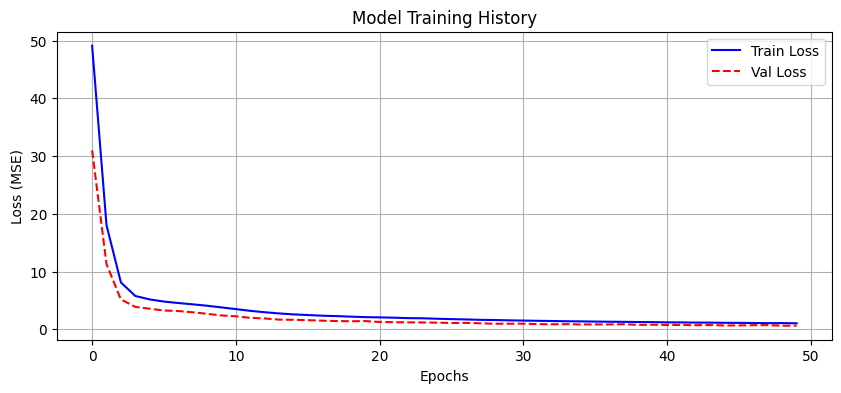

Training history plot generated.


In [89]:
manager.plot_history()
print("Training history plot generated.")

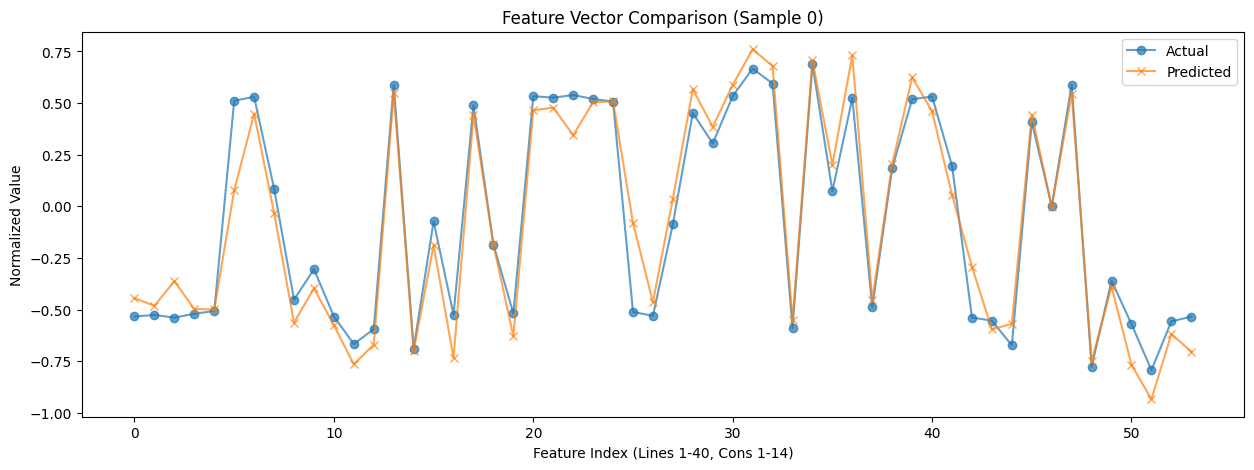

Sample comparison plot generated.


In [91]:
manager.plot_sample_comparison(y_val_windowed, y_pred, sample_idx=0)
print("Sample comparison plot generated.")

In [92]:
torch.save(manager.model.state_dict(), 'xtm_model.pt')
print("Model saved to xtm_model.pt")

Model saved to xtm_model.pt
